# Project :- TELECOM CUSTOMER CHURN ANALYSIS

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

sns.set(style="whitegrid")

#Load Dataset

In [2]:
df = pd.read_csv("telecom_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Data Understanding

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#Data Cleaning

In [4]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

<ipython-input-4-9b0f14f2ed33>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


#Key KPIs

In [5]:
# Churn Rate
churn_rate = df['Churn'].mean() * 100
print("📌 Churn Rate:", churn_rate)

# Average Tenure
avg_tenure = df['tenure'].mean()
print("📌 Average Tenure:", avg_tenure)

# ARPU
arpu = df['MonthlyCharges'].mean()
print("📌 Average Revenue Per User:", arpu)

📌 Churn Rate: 26.536987079369588
📌 Average Tenure: 32.37114865824223
📌 Average Revenue Per User: 64.76169246059918


# Visualizations

#Churn Count

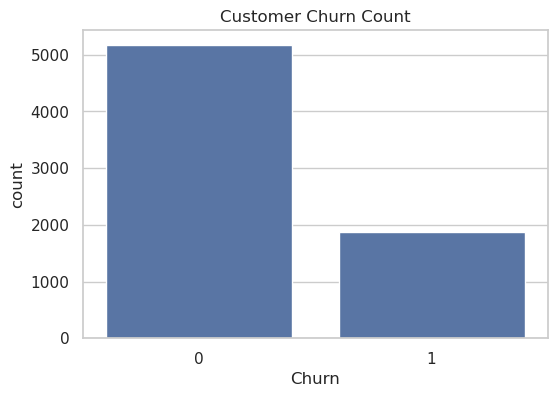

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Count")
plt.show()

#Churn by Gender

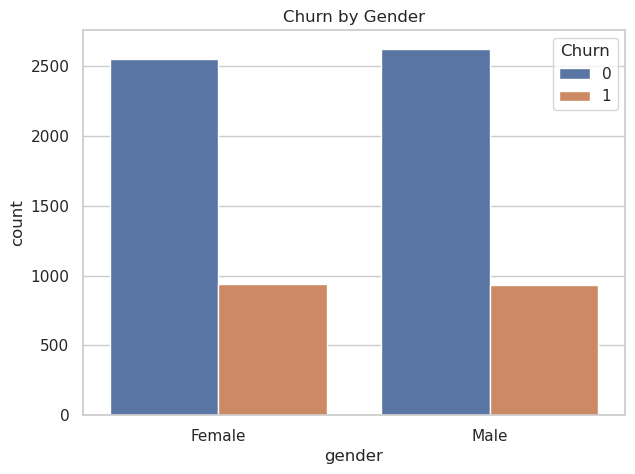

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Churn by Gender")
plt.show()

#Churn by Contract Type

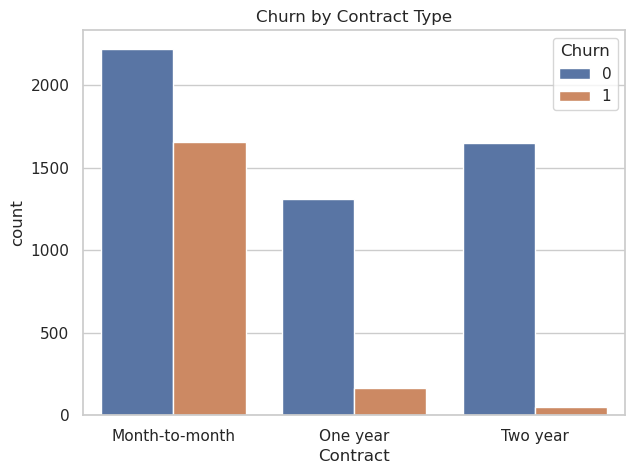

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

#Monthly Charges Distribution

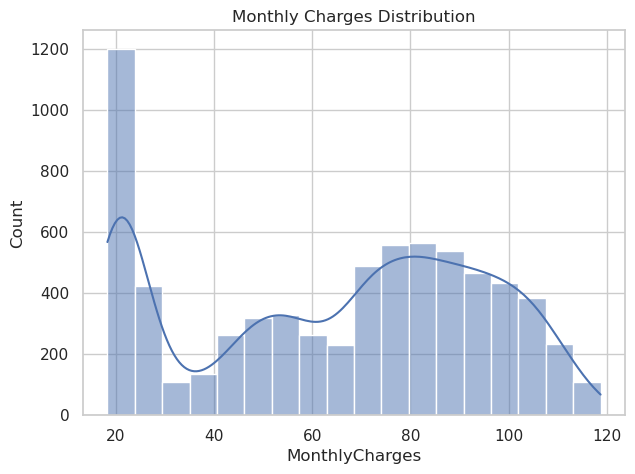

In [10]:
plt.figure(figsize=(7,5))
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

#Tenure vs Churn

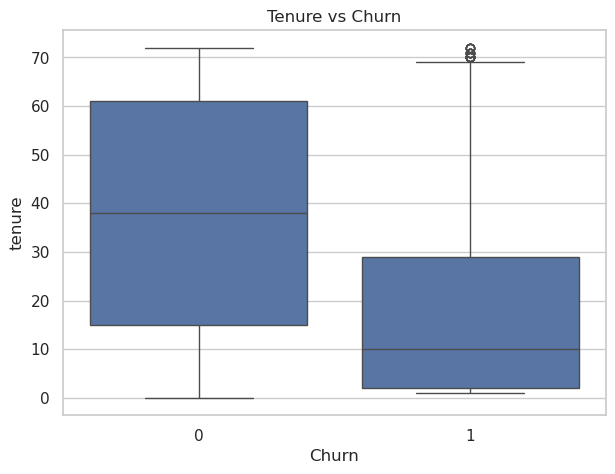

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

#Internet Service vs Churn

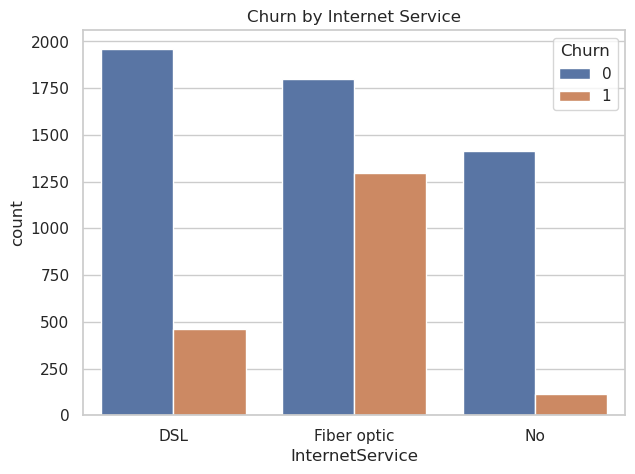

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

#Segment-based Insights

In [13]:
df.groupby('InternetService')['Churn'].mean() * 100
df.groupby('Contract')['Churn'].mean() * 100
df.groupby('PaymentMethod')['Churn'].mean() * 100

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64

#Generate Summary Insights

In [14]:
insights = {
    "Churn Rate (%)": churn_rate,
    "Average Tenure": avg_tenure,
    "ARPU": arpu,
    "Highest Churn Internet Service": df.groupby('InternetService')['Churn'].mean().idxmax(),
    "Highest Churn Contract Type": df.groupby('Contract')['Churn'].mean().idxmax(),
}
insights

{'Churn Rate (%)': np.float64(26.536987079369588),
 'Average Tenure': np.float64(32.37114865824223),
 'ARPU': np.float64(64.76169246059918),
 'Highest Churn Internet Service': 'Fiber optic',
 'Highest Churn Contract Type': 'Month-to-month'}